# Level 2 — Task 1: Regression Analysis
**Codveda Technology | Data Analytics Internship**

> **Dataset:** `4_house_Prediction_Data_Set.csv` (Boston Housing) | **Tools:** Python, scikit-learn, pandas, matplotlib
>
> **Objective:** Split data into train/test sets, fit a linear regression model, interpret coefficients, and evaluate using R², MSE, and RMSE.


## Step 1 — Imports and Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings, os

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", font_scale=1.1)

plt.rcParams.update({
    "figure.dpi": 120
})

os.makedirs("outputs/level2/regression_plots", exist_ok=True)

print("Ready.")

Ready.


## Step 2 — Load the Dataset

In [2]:
BOSTON_COLUMNS = ["CRIM","ZN","INDUS","CHAS","NOX","RM",
                   "AGE","DIS","RAD","TAX","PTRATIO","B","LSTAT","MEDV"]

df = pd.read_csv("4_house_Prediction_Data_Set.csv", header=None,
                 sep=r"\s+", engine="python", on_bad_lines="skip")
df.columns = BOSTON_COLUMNS[:df.shape[1]]
df.dropna(inplace=True)
df = df.astype(float)

print(f"Shape: {df.shape}")
print(f"\nTarget (MEDV) — Median home value in $1,000s")
print(df["MEDV"].describe().round(2))
df.head()

Shape: (506, 14)

Target (MEDV) — Median home value in $1,000s
count    506.00
mean      22.53
std        9.20
min        5.00
25%       17.02
50%       21.20
75%       25.00
max       50.00
Name: MEDV, dtype: float64


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,36.2


## Step 3 — Feature Correlations with Target (MEDV)

In [3]:
corr = df.corr()["MEDV"].drop("MEDV").sort_values()
print("Correlations with MEDV:")
print(corr.round(3))

Correlations with MEDV:
LSTAT     -0.738
PTRATIO   -0.508
INDUS     -0.484
TAX       -0.469
NOX       -0.427
CRIM      -0.388
RAD       -0.382
AGE       -0.377
CHAS       0.175
DIS        0.250
B          0.333
ZN         0.360
RM         0.695
Name: MEDV, dtype: float64


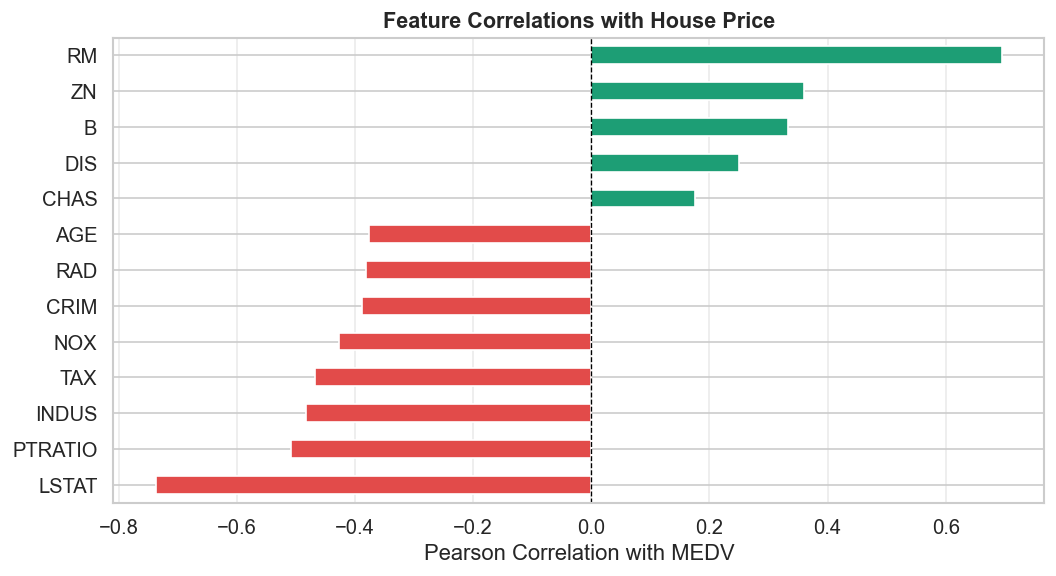

In [4]:
fig, ax = plt.subplots(figsize=(9, 5))
colors = ["#E24B4A" if v < 0 else "#1D9E75" for v in corr]
corr.plot(kind="barh", ax=ax, color=colors, edgecolor="white")
ax.axvline(0, color="black", lw=0.8, ls="--")
ax.set_xlabel("Pearson Correlation with MEDV")
ax.set_title("Feature Correlations with House Price", fontsize=13, fontweight="bold")
ax.xaxis.grid(True, alpha=0.4)
plt.tight_layout(); plt.savefig("outputs/level2/regression_plots/feature_correlations.png"); plt.show()

## Step 4 — Train / Test Split (80/20)

In [5]:
X = df.drop("MEDV", axis=1)
y = df["MEDV"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training samples : {len(X_train)}")
print(f"Testing samples  : {len(X_test)}")

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)
print("Features scaled with StandardScaler ✓")

Training samples : 404
Testing samples  : 102
Features scaled with StandardScaler ✓


## Step 5 — Fit Linear Regression Model

In [6]:
model = LinearRegression()
model.fit(X_train_sc, y_train)

coeff_df = pd.DataFrame({"Feature": X.columns, "Coefficient": model.coef_}
                         ).sort_values("Coefficient", key=abs, ascending=False)
print(f"Intercept: {model.intercept_:.3f}")
print("\nCoefficients (sorted by magnitude):")
coeff_df.round(3)

Intercept: 22.797

Coefficients (sorted by magnitude):


,Feature,Coefficient
12,LSTAT,-3.612
5,RM,3.145
7,DIS,-3.082
8,RAD,2.251
10,PTRATIO,-2.038
4,NOX,-2.022
9,TAX,-1.767
11,B,1.130
0,CRIM,-1.002
3,CHAS,0.719


## Step 6 — Evaluate the Model

In [7]:
y_pred = model.predict(X_test_sc)

r2   = r2_score(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test, y_pred)

print(f"R²   (test)  : {r2:.4f}")
print(f"MSE  (test)  : {mse:.4f}")
print(f"RMSE (test)  : {rmse:.4f}")
print(f"MAE  (test)  : {mae:.4f}")

cv_r2 = cross_val_score(model, scaler.transform(X), y, cv=5, scoring="r2")
print(f"\n5-Fold CV R² : {cv_r2.mean():.4f} ± {cv_r2.std():.4f}")

R²   (test)  : 0.6688
MSE  (test)  : 24.2911
RMSE (test)  : 4.9286
MAE  (test)  : 3.1891

5-Fold CV R² : 0.3533 ± 0.3766


## Step 7 — Diagnostic Plots

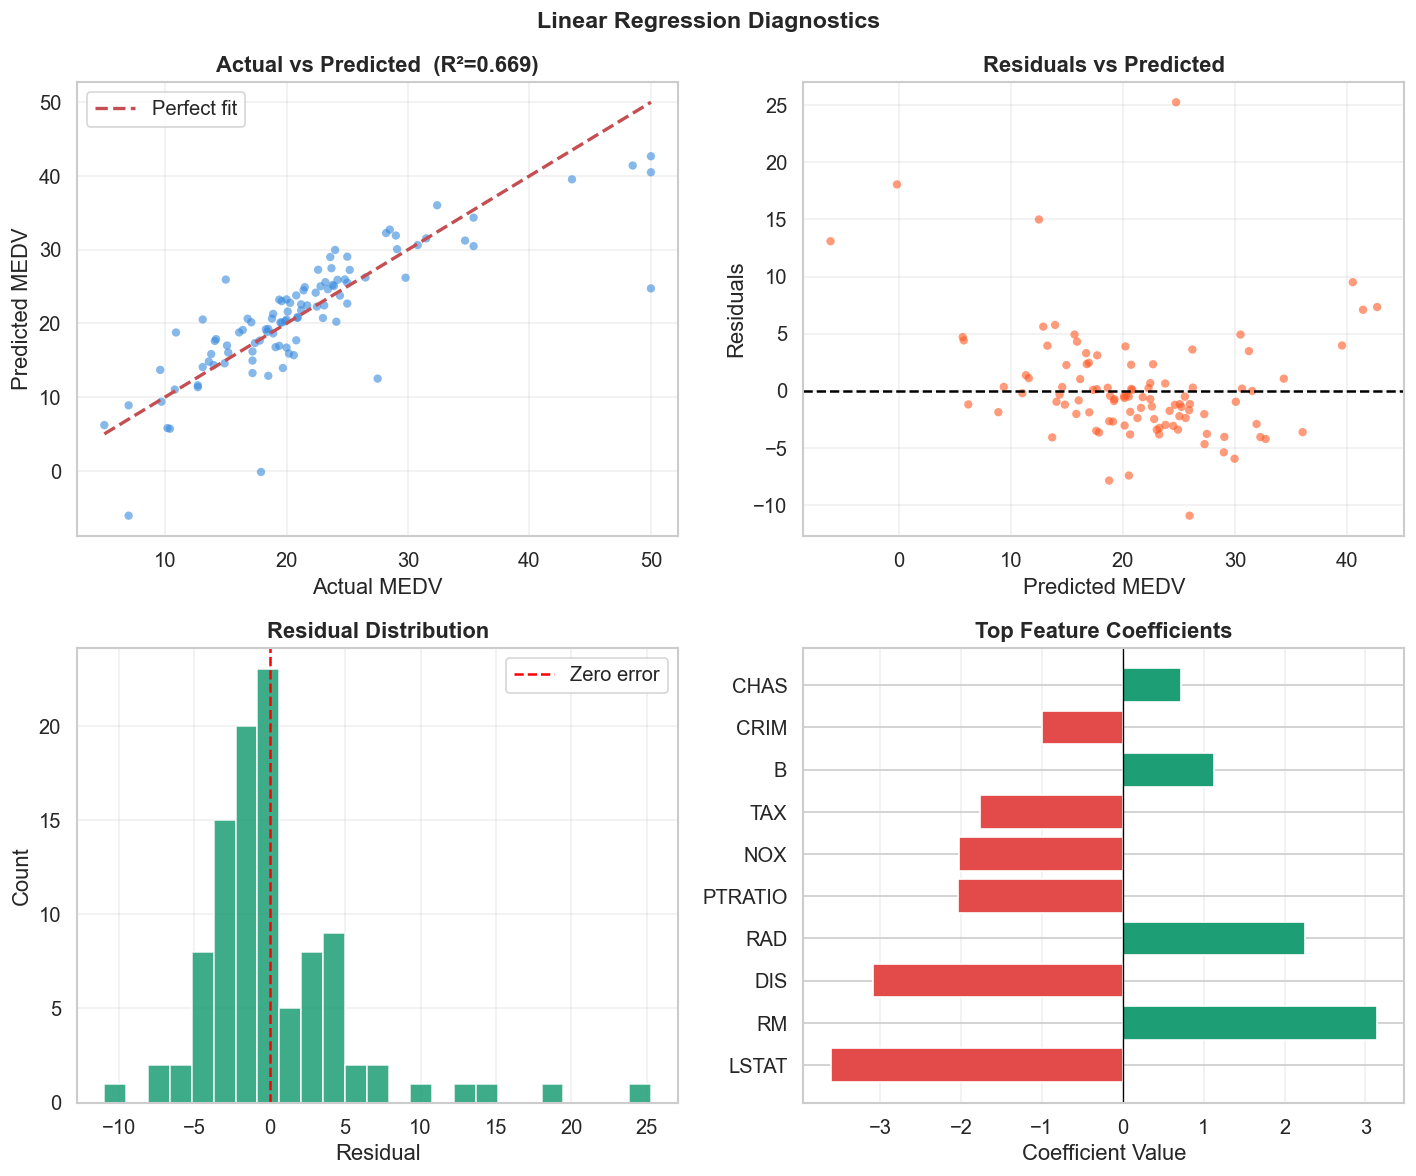

In [8]:
residuals = y_test - y_pred

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle("Linear Regression Diagnostics", fontsize=14, fontweight="bold")

# Actual vs Predicted
ax = axes[0,0]
ax.scatter(y_test, y_pred, alpha=0.6, s=25, color="#378ADD", edgecolors="none")
lo, hi = y_test.min(), y_test.max()
ax.plot([lo,hi],[lo,hi],"r--",lw=2,label="Perfect fit")
ax.set_xlabel("Actual MEDV"); ax.set_ylabel("Predicted MEDV")
ax.set_title(f"Actual vs Predicted  (R²={r2:.3f})", fontweight="bold")
ax.legend(); ax.grid(alpha=0.3)

# Residuals vs Predicted
ax = axes[0,1]
ax.scatter(y_pred, residuals, alpha=0.6, s=25, color="#FF5722", edgecolors="none")
ax.axhline(0, color="black", lw=1.5, ls="--")
ax.set_xlabel("Predicted MEDV"); ax.set_ylabel("Residuals")
ax.set_title("Residuals vs Predicted", fontweight="bold"); ax.grid(alpha=0.3)

# Residual histogram
ax = axes[1,0]
ax.hist(residuals, bins=25, color="#1D9E75", edgecolor="white", alpha=0.85)
ax.axvline(0, color="red", lw=1.5, ls="--", label="Zero error")
ax.set_xlabel("Residual"); ax.set_ylabel("Count")
ax.set_title("Residual Distribution", fontweight="bold"); ax.legend(); ax.grid(alpha=0.3)

# Feature coefficients
ax = axes[1,1]
top = coeff_df.head(10)
colors_c = ["#E24B4A" if v < 0 else "#1D9E75" for v in top["Coefficient"]]
ax.barh(top["Feature"], top["Coefficient"], color=colors_c, edgecolor="white")
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("Coefficient Value"); ax.set_title("Top Feature Coefficients", fontweight="bold")
ax.grid(alpha=0.3, axis="x")

plt.tight_layout()
plt.savefig("outputs/level2/regression_plots/regression_diagnostics.png")
plt.show()